# YOLO Training

## Datasets

In [ ]:
pip install ultralytics

In [ ]:
import kagglehub

# Dataset >35k
path = kagglehub.dataset_download("roscoekerby/firesmoke-detection-yolo-v9")

print("Path to dataset files:", path)

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")

print("Path to dataset files:", path)

# Data Prep (Optional)

In [ ]:
import os
train_imgs = f"{path}/data/train/images"
train_lbls = f"{path}/data/train/labels"

num_images = len(os.listdir(train_imgs))
num_labels = len(os.listdir(train_lbls))

print("Images:", num_images)
print("Labels:", num_labels)

from PIL import Image

sizes = []

for file in os.listdir(train_imgs)[:500]:
    img = Image.open(os.path.join(train_imgs, file))
    sizes.append(img.size)

print(set(sizes))

In [ ]:
import os
import shutil
from PIL import Image

src = f"{path}/data"
dst = "/kaggle/working/firesmoke_cleaned"

min_size = 400

valid_count = 0
skipped_small = 0
skipped_no_label = 0
skipped_empty_label = 0

for split in ["train", "valid", "test"]:
    img_src = os.path.join(src, split, "images")
    lbl_src = os.path.join(src, split, "labels")

    img_dst = os.path.join(dst, split, "images")
    lbl_dst = os.path.join(dst, split, "labels")

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    for file in os.listdir(img_src):
        img_path = os.path.join(img_src, file)
        label_file = file.rsplit(".", 1)[0] + ".txt"
        lbl_path = os.path.join(lbl_src, label_file)

        try:
            # Check image
            img = Image.open(img_path)
            w, h = img.size

            if w < min_size or h < min_size:
                skipped_small += 1
                continue

            # Label exists?
            if not os.path.exists(lbl_path):
                skipped_no_label += 1
                continue

            # Label empty?
            if os.path.getsize(lbl_path) == 0:
                skipped_empty_label += 1
                continue

            # Validate label-content
            valid_lines = []
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    try:
                        int(parts[0])                # class
                        list(map(float, parts[1:]))  # bbox
                        valid_lines.append(line)
                    except:
                        continue

            if len(valid_lines) == 0:
                skipped_empty_label += 1
                continue

            # Copy (valid data only)
            shutil.copy(img_path, img_dst)

            with open(os.path.join(lbl_dst, label_file), "w") as f:
                f.writelines(valid_lines)

            valid_count += 1

        except Exception as e:
            continue

print("✅ Done!")
print(f"✔ Valid images: {valid_count}")
print(f"❌ Too small: {skipped_small}")
print(f"❌ No Label: {skipped_no_label}")
print(f"❌ Empty/broken Labels: {skipped_empty_label}")

In [ ]:
import os
import random
import shutil
from collections import defaultdict

src = "/kaggle/working/firesmoke_cleaned"
dst = "/kaggle/working/firesmoke_balanced"

for split in ["train", "valid", "test"]:
    print(f"\n🔹 Processing {split}...")

    img_src = os.path.join(src, split, "images")
    lbl_src = os.path.join(src, split, "labels")

    img_dst = os.path.join(dst, split, "images")
    lbl_dst = os.path.join(dst, split, "labels")

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    class_to_files = defaultdict(list)

    for file in os.listdir(lbl_src):
        label_path = os.path.join(lbl_src, file)

        classes = set()

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                try:
                    class_id = int(parts[0])
                    classes.add(class_id)
                except:
                    continue

        img_file = file.replace(".txt", ".jpg")


        if not os.path.exists(os.path.join(img_src, img_file)):
            continue

        for c in classes:
            class_to_files[c].append(img_file)


    min_count = min(len(v) for v in class_to_files.values())
    print("Min samples per class:", min_count)

    selected_images = set()

    for c, files in class_to_files.items():
        sampled = random.sample(files, min_count)
        selected_images.update(sampled)

    print("Total selected images:", len(selected_images))

    for img in selected_images:
        src_img_path = os.path.join(img_src, img)
        src_lbl_path = os.path.join(lbl_src, img.replace(".jpg", ".txt"))

        shutil.copy(src_img_path, os.path.join(img_dst, img))
        shutil.copy(src_lbl_path, os.path.join(lbl_dst, img.replace(".jpg", ".txt")))

print("\n✅ Balancing Done!")

## Training

In [ ]:
from ultralytics import YOLO
# Start with pre-trained
model = YOLO("yolo26n.pt")

# “short” Training
results = model.train(data="/kaggle/input/smoke-fire-detection-yolo", epochs=30, imgsz=640, fraction=0.2)#device=0 for gpu

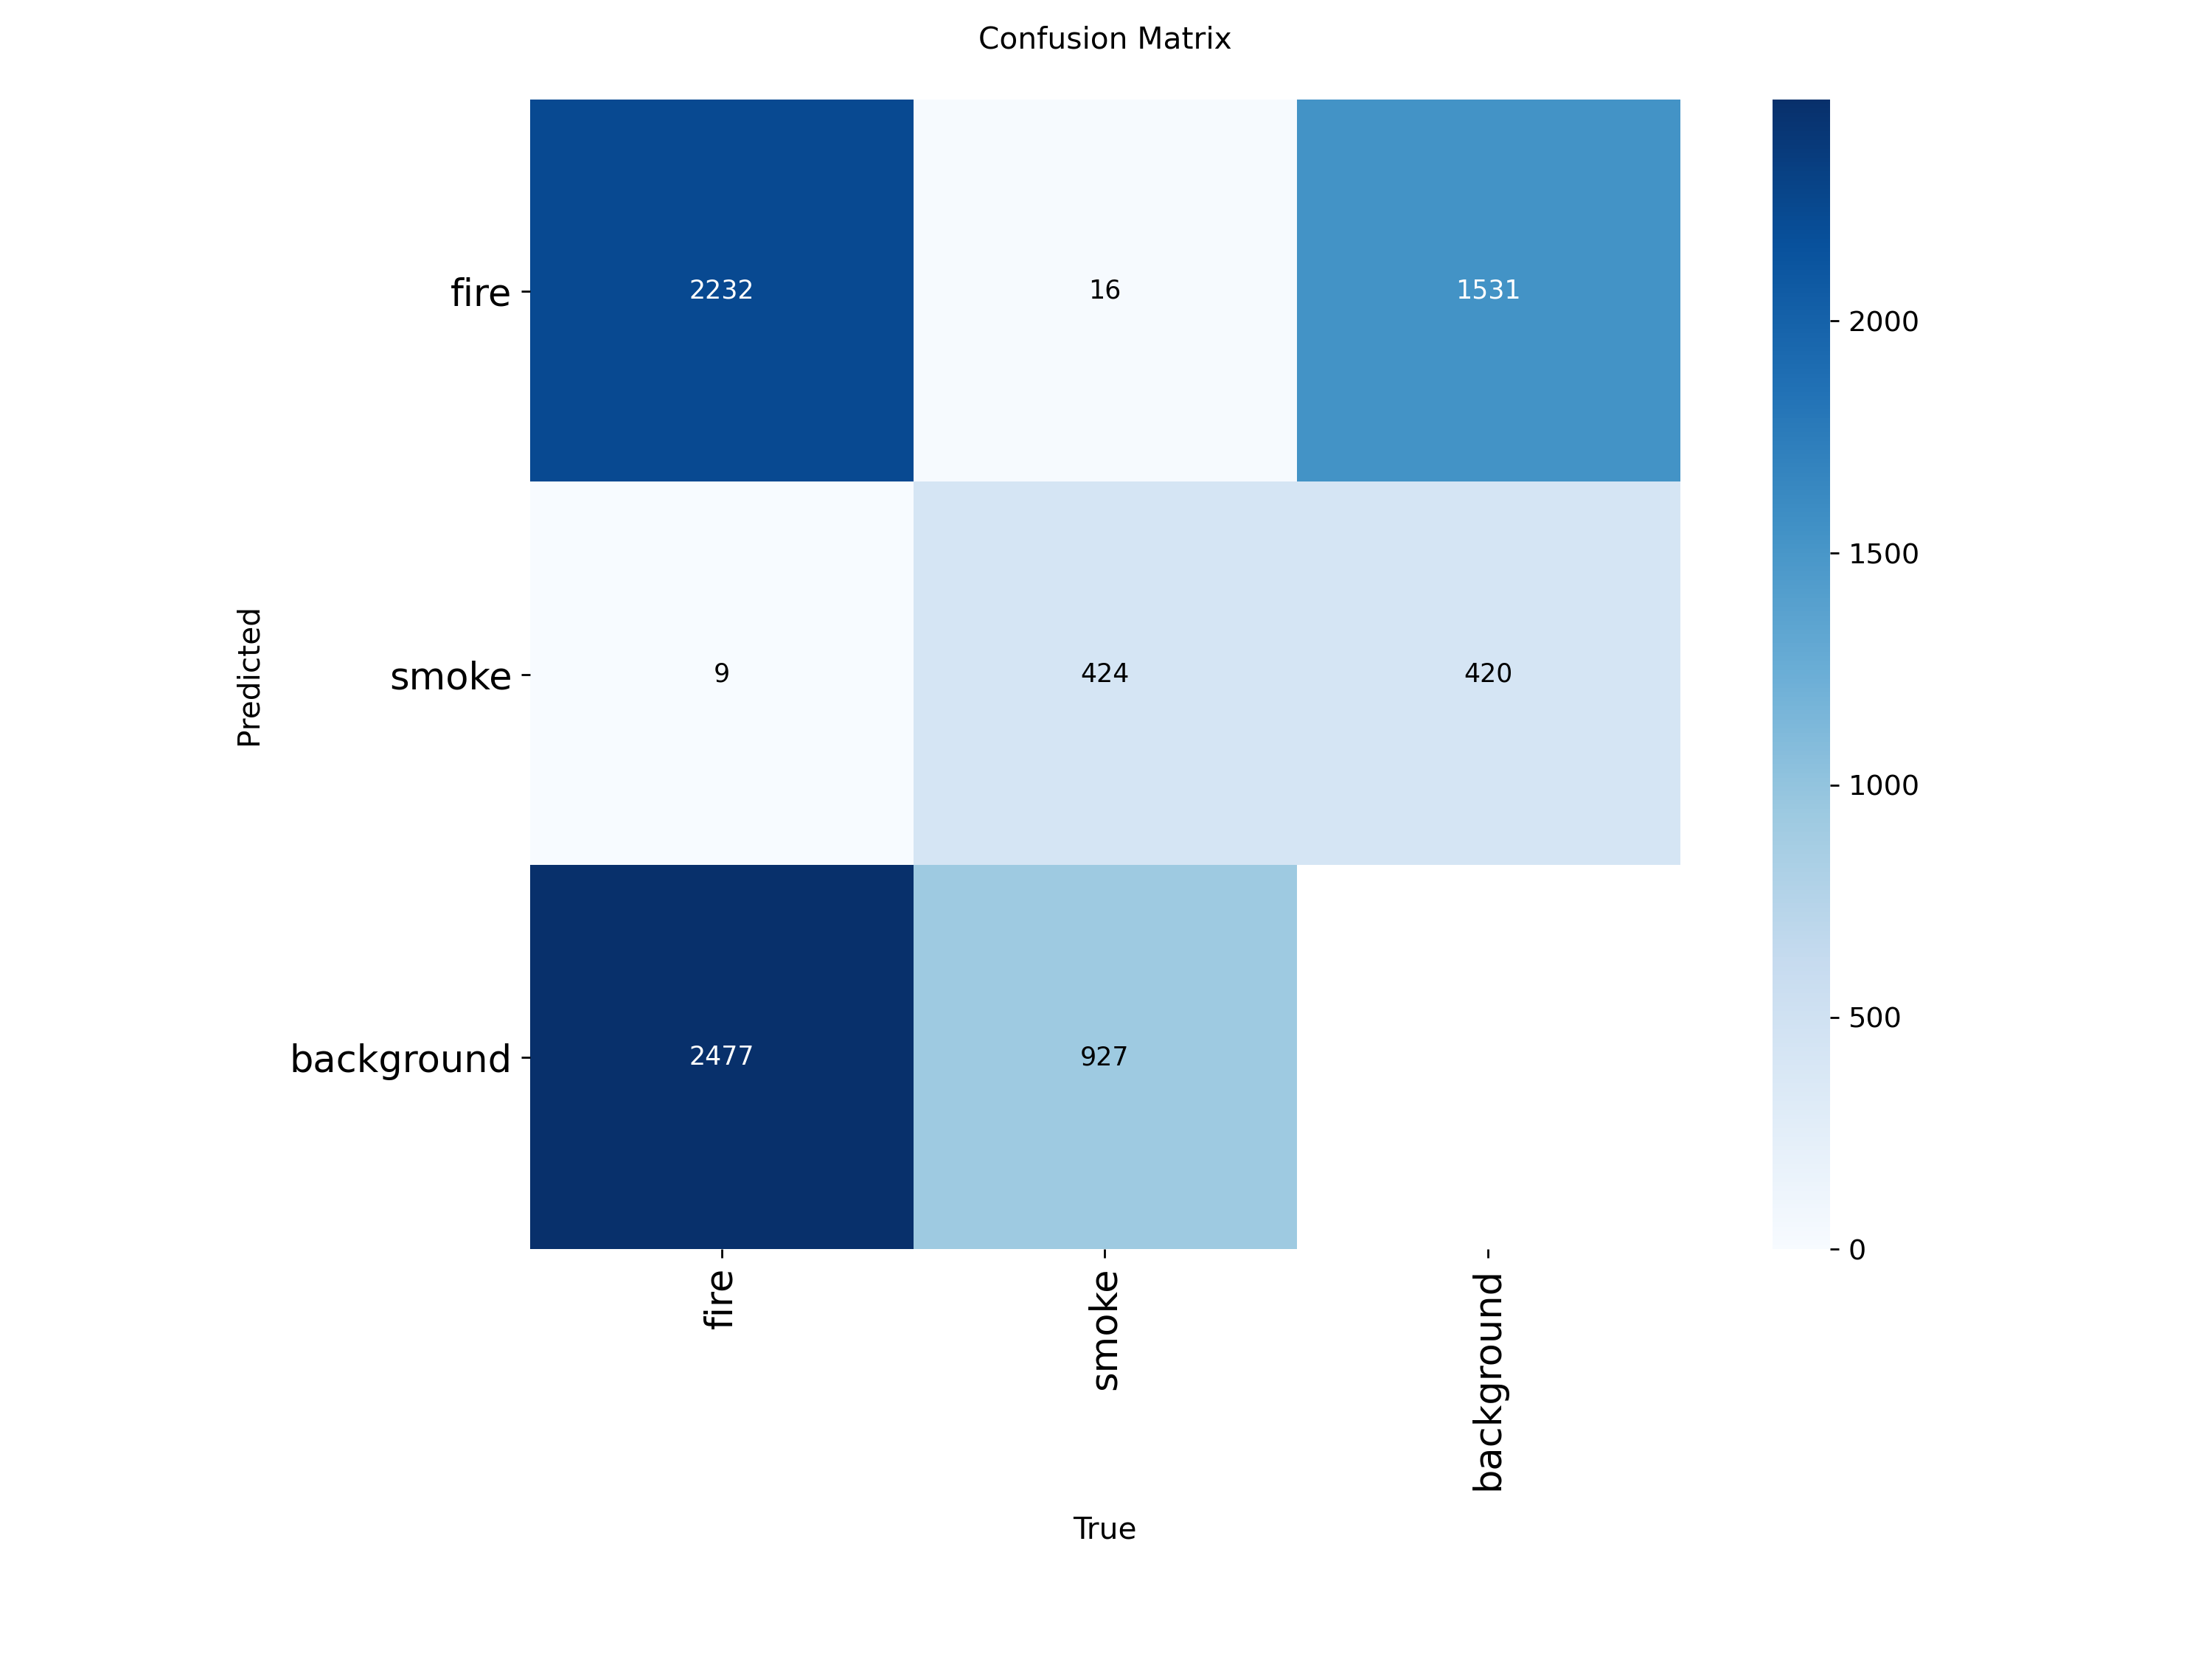

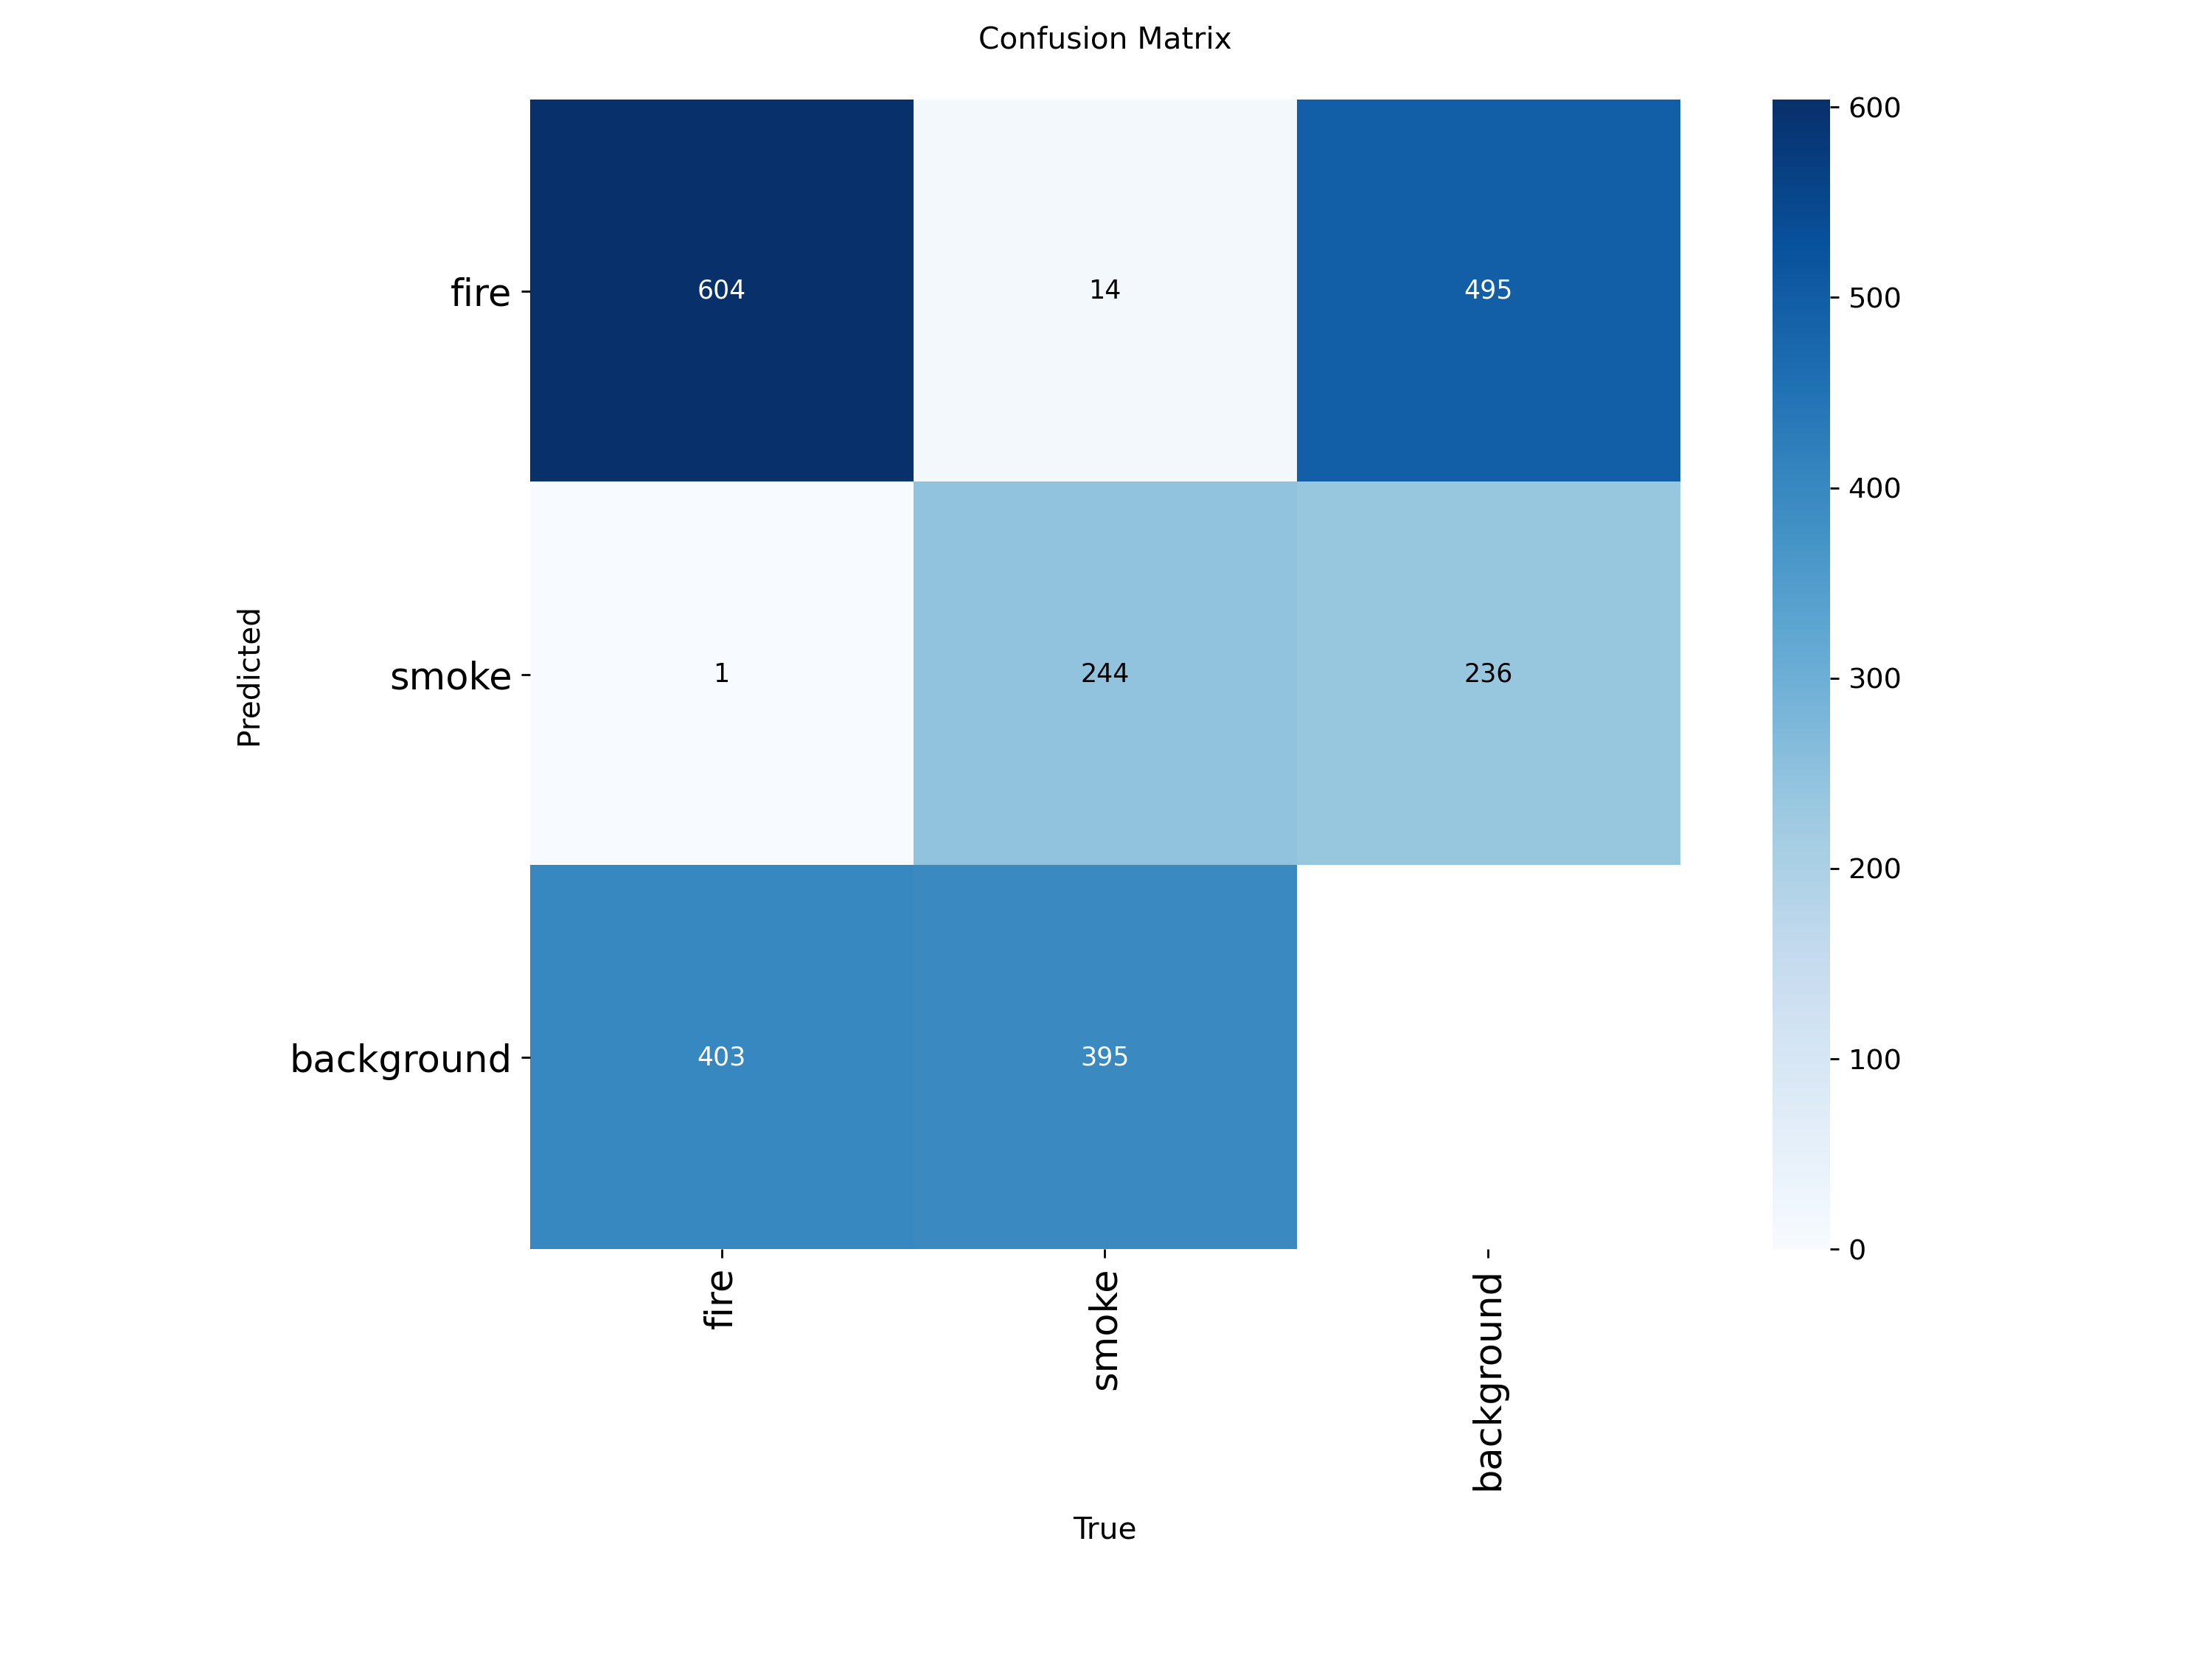

Ausbaufähig...